# TP Chimie & IA : Classification binaire avec un neurone (Fonction Sigmoïde)
## Détection de composés chimiques actifs ou inactifs (solubilité et polarité)

**Nom de l'étudiant :** ______________________  
**Prénom de l'étudiant :** ______________________  
**Date :** 02 juin 2026

---

### Contexte théorique du TP

En chimie médicinale, on cherche souvent à classer des molécules comme **actives** (Classe 1) ou **inactives** (Classe 0) selon leurs propriétés physico-chimiques. Dans ce TP, nous allons étudier deux descripteurs moléculaires clés :
1. Le **LogP** (Coefficient de partage octanol-eau), qui mesure le caractère hydrophobe de la molécule.
2. La **PSA (Polar Surface Area) divisée par 10**, qui mesure la surface polaire de la molécule (liée à sa capacité à former des liaisons hydrogène).

Contrairement au TP précédent (loi de Beer-Lambert) où la relation était purement continue et linéaire, nous voulons ici réaliser une **classification binaire** (séparer deux classes distinctes de points).

#### Le neurone de classification binaire :
Pour effectuer une classification binaire, un seul neurone calcule d'abord une combinaison linéaire de ses entrées $x_1$ ($\text{LogP}$) et $x_2$ ($\text{PSA}/10$) :
$$z = W_1 \cdot x_1 + W_2 \cdot x_2 + b$$

Pour convertir cette valeur continue $z$ en une **probabilité** entre $0$ et $1$, on applique la fonction d'activation **Sigmoïde** (notée $\sigma$) :
$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

* Si $\hat{y} \ge 0.5$ (ce qui correspond à $z \ge 0$), la molécule est classée comme **Active** (Classe 1).
* Si $\hat{y} < 0.5$ (ce qui correspond à $z < 0$), la molécule est classée comme **Inactive** (Classe 0).

La frontière entre les deux classes est la droite d'équation $z = 0$, soit :
$$W_1 \cdot x_1 + W_2 \cdot x_2 + b = 0$$

---

In [1]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras import initializers
from keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

print("Version de TensorFlow :", tf.__version__)

Version de TensorFlow : 2.14.0


## Partie 1 : Génération et visualisation des données chimiques

Nous allons générer un jeu de données synthétique contenant 100 molécules :
* 50 molécules **actives** (solubles, LogP faible et PSA élevée).
* 50 molécules **inactives** (peu solubles, LogP élevé et PSA faible).

Exécutez la cellule ci-dessous pour générer et tracer ces molécules.

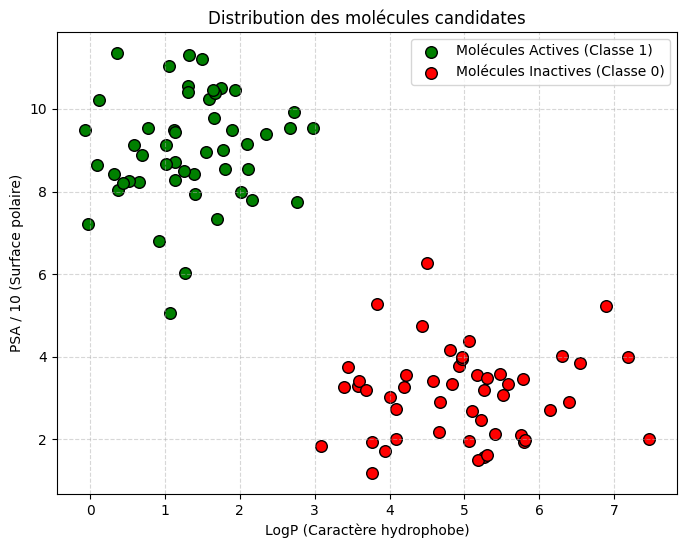

In [2]:
# Fixer la graine aléatoire pour la reproductibilité
np.random.seed(42)

# Classe 1 : Molécules actives (LogP faible, PSA élevée) - 50 composés
logP_active = np.random.normal(loc=1.5, scale=0.8, size=50)
PSA_active = np.random.normal(loc=9.0, scale=1.5, size=50)
X_active = np.column_stack((logP_active, PSA_active))
y_active = np.ones(50)

# Classe 0 : Molécules inactives (LogP élevé, PSA faible) - 50 composés
logP_inactive = np.random.normal(loc=5.0, scale=1.0, size=50)
PSA_inactive = np.random.normal(loc=3.0, scale=1.2, size=50)
X_inactive = np.column_stack((logP_inactive, PSA_inactive))
y_inactive = np.zeros(50)

# Fusionner les deux classes
X = np.vstack((X_active, X_inactive))
y = np.concatenate((y_active, y_inactive))

# Visualisation des molécules
plt.figure(figsize=(8, 6))
plt.scatter(X_active[:, 0], X_active[:, 1], color='green', label='Molécules Actives (Classe 1)', edgecolors='k', s=70)
plt.scatter(X_inactive[:, 0], X_inactive[:, 1], color='red', label='Molécules Inactives (Classe 0)', edgecolors='k', s=70)
plt.xlabel('LogP (Caractère hydrophobe)')
plt.ylabel('PSA / 10 (Surface polaire)')
plt.title('Distribution des molécules candidates')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Partie 2 : Construction et entraînement du neurone de classification

Pour la classification binaire, nous utilisons :
* Une couche `Dense` avec 1 seul neurone, 2 entrées (`input_shape=[2]`), et l'activation `'sigmoid'`.
* L'optimiseur `Adam` avec un taux d'apprentissage de $0.1$.
* La fonction de perte `'binary_crossentropy'` (entropie croisée binaire), parfaitement adaptée à la classification binaire (contrairement au MSE de la régression linéaire).

Lisez attentivement le code ci-dessous et exécutez-le.

In [3]:
# 1. Construction du modèle (1 neurone, 2 entrées, activation sigmoïde)
model = Sequential()
model.add(Dense(units=1, input_shape=[2], activation='sigmoid', kernel_initializer=initializers.RandomNormal(stddev=0.1)))

# 2. Compilation (Perte : binary_crossentropy, Optimiseur : Adam)
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.1), metrics=['accuracy'])

# 3. Entraînement sur 150 epochs
print("Début de l'entraînement...")
historique = model.fit(X, y, epochs=50, verbose=1)
print("Entraînement terminé !")

Début de l'entraînement...
Epoch 1/50
4/4 [==============================] - 0s 3ms/step - loss: 0.9681 - accuracy: 0.4300
Epoch 2/50
4/4 [==============================] - 0s 2ms/step - loss: 0.2984 - accuracy: 0.9400
Epoch 3/50
4/4 [==============================] - 0s 2ms/step - loss: 0.1240 - accuracy: 0.9900
Epoch 4/50
4/4 [==============================] - 0s 2ms/step - loss: 0.0508 - accuracy: 1.0000
Epoch 5/50
4/4 [==============================] - 0s 2ms/step - loss: 0.0283 - accuracy: 1.0000
Epoch 6/50
4/4 [==============================] - 0s 2ms/step - loss: 0.0212 - accuracy: 1.0000
Epoch 7/50
4/4 [==============================] - 0s 2ms/step - loss: 0.0179 - accuracy: 1.0000
Epoch 8/50
4/4 [==============================] - 0s 2ms/step - loss: 0.0152 - accuracy: 1.0000
Epoch 9/50
4/4 [==============================] - 0s 2ms/step - loss: 0.0131 - accuracy: 1.0000
Epoch 10/50
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - accuracy: 1.0000
Epoch 11/50


## Partie 3 : Visualisation de la frontière de décision apprise par le neurone

La frontière de décision sépare la région prédite "Active" (Classe 1) de la région prédite "Inactive" (Classe 0). Elle correspond à l'équation :
$$W_1 \cdot \text{LogP} + W_2 \cdot \text{PSA}/10 + b = 0$$

Ce qui donne la droite :
$$\text{PSA}/10 = - \frac{W_1}{W_2} \cdot \text{LogP} - \frac{b}{W_2}$$

Exécutez le code ci-dessous pour tracer la frontière de décision obtenue par le neurone.


--- Paramètres appris par le neurone ---


Poids W1 (associé à LogP) : -2.4187
Poids W2 (associé à PSA/10) : 1.2516
Biais b : -0.0953



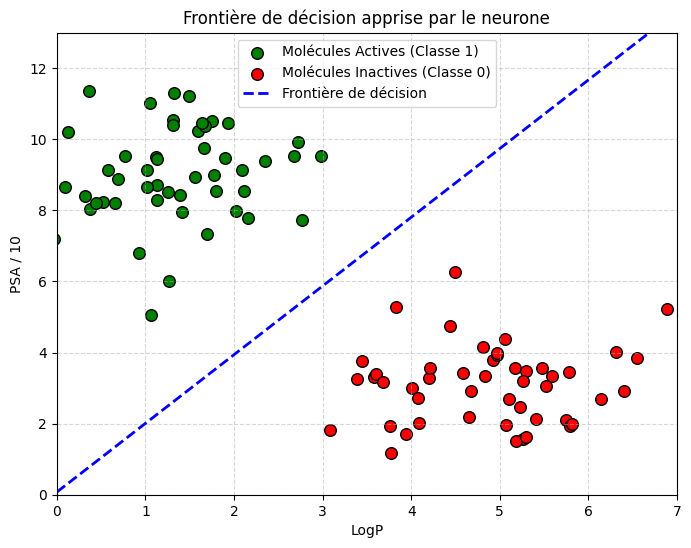

In [4]:
# Récupération des paramètres appris
weights, bias = model.get_weights()
W1 = weights[0][0]
W2 = weights[1][0]
b = bias[0]

print(f"\n--- Paramètres appris par le neurone ---")
print(f"Poids W1 (associé à LogP) : {W1:.4f}")
print(f"Poids W2 (associé à PSA/10) : {W2:.4f}")
print(f"Biais b : {b:.4f}\n")

# Tracé de la frontière de décision
plt.figure(figsize=(8, 6))

# Points expérimentaux
plt.scatter(X_active[:, 0], X_active[:, 1], color='green', label='Molécules Actives (Classe 1)', edgecolors='k', s=70)
plt.scatter(X_inactive[:, 0], X_inactive[:, 1], color='red', label='Molécules Inactives (Classe 0)', edgecolors='k', s=70)

# Calcul de la droite de frontière
x_vals = np.linspace(0, 7, 100)
y_vals = -(W1 * x_vals + b) / W2
plt.plot(x_vals, y_vals, color='blue', linestyle='--', linewidth=2, label='Frontière de décision')

plt.xlim(0, 7)
plt.ylim(0, 13)
plt.xlabel('LogP')
plt.ylabel('PSA / 10')
plt.title('Frontière de décision apprise par le neurone')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Partie 4 : Questions d'analyse pour les étudiants de chimie

Répondez aux questions ci-dessous en double-cliquant sur les cellules de réponse.

### Question 1 : Le rôle de la fonction d'activation
Expliquez pourquoi l'utilisation d'une fonction d'activation **Sigmoïde** (non linéaire) est indispensable pour ce problème de classification. Que se passerait-il si nous utilisions une fonction d'activation linéaire (comme pour le TP sur la loi de Beer-Lambert) ?

> **Votre réponse :**  
> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

### Question 2 : Signification physique des poids appris
Regardez les valeurs des poids $W_1$ (associé au LogP) et $W_2$ (associé à la surface polaire PSA/10).
* Quel est le signe de $W_1$ ? Quelle est l'influence d'une augmentation du LogP sur la probabilité que la molécule soit active ? Est-ce cohérent d'un point de vue chimique (sachant que les molécules actives doivent être solubles) ?
* Quel est le signe de $W_2$ ? Quelle est l'influence d'une augmentation de la surface polaire PSA/10 sur la probabilité d'activité ?

> **Votre réponse :**  
> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

### Question 3 : Étude de l'époque d'entraînement
Modifiez le nombre d'epochs dans la **Partie 2** à `epochs=1` puis relancez l'entraînement et le tracé de la frontière de décision.
* Qu'observez-vous sur la frontière de décision ? Est-elle capable de bien séparer les deux types de molécules ?
* Expliquez brièvement pourquoi le modèle nécessite un certain nombre d'epochs pour apprendre la frontière optimale.
*(Pensez à remettre `epochs=150` et à ré-exécuter les cellules après vos observations).*

> **Votre réponse :**  
> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

### Question 4 : Prédiction pour un nouveau candidat médicament
Un nouveau candidat médicament présente les propriétés moléculaires suivantes :
*   $\text{LogP} = 3.0$
*   $\text{PSA}/10 = 7.5$

Utilisez la cellule de code ci-dessous pour prédire la probabilité que ce composé soit actif, puis indiquez si la molécule est classée dans la catégorie active ou inactive.

In [5]:
# TODO : Entrez les valeurs de la nouvelle molécule
nouveau_LogP = 3.0
nouveau_PSA_div10 = 7.5

# Préparation de l'entrée pour Keras (doit être sous forme de tableau 2D)
nouvelle_molecule = np.array([[nouveau_LogP, nouveau_PSA_div10]], dtype=float)

# Prédiction de la probabilité par le neurone
probabilite = model.predict(nouvelle_molecule)[0][0]

print(f"\n--- Prédiction du modèle ---")
print(f"Probabilité que la molécule soit ACTIVE : {probabilite * 100:.2f}%")
if probabilite >= 0.5:
    print("Classification : LA MOLÉCULE EST ACTIVE (Classe 1)")
else:
    print("Classification : LA MOLÉCULE EST INACTIVE (Classe 0)")

1/1 [==============================] - 0s 78ms/step

--- Prédiction du modèle ---
Probabilité que la molécule soit ACTIVE : 88.45%
Classification : LA MOLÉCULE EST ACTIVE (Classe 1)
